# Prequential Evaluation of Surrogate Models — Function 3

**Objective**: Compare three surrogate model families on the drug discovery problem (Function 3) using **prequential (one-step-ahead) evaluation**.

## Function 3 Properties

| Property | Value |
|----------|-------|
| Problem | Drug discovery — minimise adverse reactions from 3 compounds |
| Input dimensions | 3 |
| Output dimensions | 1 |
| Objective | Maximise (transformed: negative of side effects) |
| Input range | [0, 1] |
| Output characteristics | Number of adverse reactions (transformed); moderate range |
| Initial samples | 15 |
| Total samples (Week 6) | 21 |
| Evaluation steps | 6 one-step-ahead predictions |

## Surrogate Models

1. **Gaussian Process (GP)** — via BoTorch/GPyTorch
2. **BART (Bayesian Additive Regression Trees)** — via PyMC-BART
3. **Random Forest (RF)** — via scikit-learn

## Methodology

For each surrogate, we:
1. Train on the initial 10 data points
2. Predict the next observation (one-step-ahead)
3. Record (prediction, uncertainty, actual)
4. Add the new point to the training set and retrain
5. Repeat until all 16 points have been processed (6 evaluation steps)

Each family is evaluated with **15 hyperparameter configurations** (45 total), and the best configuration from each family is compared in a 3-way comparison.

## Evaluation Metrics

We evaluate each surrogate using three metrics:

1. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values. Lower is better.

2. **NLP (Negative Log Predictive Density)**: Measures calibration quality — penalises both inaccurate means and overconfident/underconfident uncertainty. Lower is better.

   $$\text{NLP}_i = \frac{1}{2} \log(2\pi\sigma_i^2) + \frac{(y_i - \mu_i)^2}{2\sigma_i^2}$$

3. **95% Coverage**: Proportion of actual values falling within the 95% prediction interval ($\mu \pm 1.96\sigma$). Ideal value is 0.95.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# BoTorch / GPyTorch for Gaussian Process
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood

# PyMC / BART
import pymc as pm
import pymc_bart as pmb

# scikit-learn for Random Forest
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
torch.manual_seed(42)
print('All imports successful.')

All imports successful.


## Step 1: Load Data

Load the Function 3 data. The `WEEK` variable controls which data snapshot to use (default: Week 6 with 16 total data points — 10 initial + 6 sequential observations).

Function 3 is a drug discovery problem with 3 input dimensions (compound concentrations) and 1 output (transformed adverse reactions — we maximise this).

In [2]:
# ── Configuration ─────────────────────────────────────────────
WEEK = 6
N_INIT = 10  # Number of initial training points

# ── Load data ─────────────────────────────────────────────────
X_all = np.load(f'../../data/f3/updated_inputs - Week {WEEK}.npy')
y_all = np.load(f'../../data/f3/updated_outputs - Week {WEEK}.npy')

# Flatten y if needed
if y_all.ndim > 1:
    y_all = y_all.flatten()

n_total = len(y_all)
n_steps = n_total - N_INIT

print(f'Function 3 — Drug Discovery (Minimise Adverse Reactions)')
print(f'  Data loaded: Week {WEEK}')
print(f'  X shape: {X_all.shape}  (input dimensions: {X_all.shape[1]})')
print(f'  y shape: {y_all.shape}')
print(f'  Output range: [{y_all.min():.6f}, {y_all.max():.6f}]')
print(f'  Output mean:  {y_all.mean():.6f}')
print(f'  Output std:   {y_all.std():.6f}')
print(f'  Initial training points: {N_INIT}')
print(f'  Evaluation steps: {n_steps}')

Function 3 — Drug Discovery (Minimise Adverse Reactions)
  Data loaded: Week 6
  X shape: (21, 3)  (input dimensions: 3)
  y shape: (21,)
  Output range: [-0.398926, -0.032221]
  Output mean:  -0.096291
  Output std:   0.078797
  Initial training points: 10
  Evaluation steps: 11


## Step 2: Define Evaluation Metrics

The `compute_metrics()` function computes MAE, NLP, and 95% Coverage from the one-step-ahead predictions.

In [3]:
def compute_metrics(predictions, actuals, pred_means, pred_stds):
    """
    Compute prequential evaluation metrics.
    
    Parameters
    ----------
    predictions : list of float — point predictions (mean) for each step
    actuals     : list of float — actual observed values for each step
    pred_means  : list of float — predicted means (same as predictions)
    pred_stds   : list of float — predicted standard deviations (uncertainty)
    
    Returns
    -------
    dict with MAE, NLP, Coverage_95, and per-step details
    """
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    pred_means = np.array(pred_means)
    pred_stds = np.array(pred_stds)
    
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    
    # Negative Log Predictive Density (NLP)
    # NLP_i = 0.5 * log(2*pi*sigma^2) + (y - mu)^2 / (2*sigma^2)
    stds_clipped = np.clip(pred_stds, 1e-10, None)
    nlp_values = 0.5 * np.log(2 * np.pi * stds_clipped**2) + \
                 (actuals - pred_means)**2 / (2 * stds_clipped**2)
    mean_nlp = np.mean(nlp_values)
    
    # 95% Prediction Interval Coverage
    lower = pred_means - 1.96 * stds_clipped
    upper = pred_means + 1.96 * stds_clipped
    in_interval = (actuals >= lower) & (actuals <= upper)
    coverage_95 = np.mean(in_interval)
    
    return {
        'MAE': mae,
        'NLP': mean_nlp,
        'Coverage_95': coverage_95,
        'nlp_values': nlp_values,
        'errors': actuals - predictions,
        'in_interval': in_interval
    }

print('compute_metrics() defined.')

compute_metrics() defined.


## Step 3: GP Prequential Evaluation

Default GP uses Matérn 5/2 kernel with ARD (Automatic Relevance Determination) across all 3 input dimensions, learned noise level, and Maximum Likelihood Estimation (MLE) fitting via `fit_gpytorch_mll`.

**Why ARD for F3**: With 3 compound concentrations as inputs, ARD allows the GP to learn different lengthscales per dimension, capturing that some compounds may have stronger effects than others.

In [4]:
def gp_prequential_evaluation(X_all, y_all, n_init):
    """
    Perform one-step-ahead prequential evaluation using a Gaussian Process.
    Default: Matern 5/2 kernel, ARD, learned noise.
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running GP (Matern 5/2) prequential evaluation...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_all[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_all[n_train]
        
        # Build and fit GP model
        model = SingleTaskGP(X_train, y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Predict
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('gp_prequential_evaluation() defined.')

gp_prequential_evaluation() defined.


### Run GP with Default Hyperparameters

In [5]:
gp_default_results = gp_prequential_evaluation(X_all, y_all, N_INIT)

Running GP (Matern 5/2) prequential evaluation...
  Training starts with 10 points, evaluating 11 steps

  Step 1: train=10 pts | predicted=-0.067948 | actual=-0.046947 | error=+0.021000 | std=0.019301
  Step 2: train=11 pts | predicted=-0.114605 | actual=-0.105965 | error=+0.008640 | std=0.032319
  Step 3: train=12 pts | predicted=-0.238118 | actual=-0.118048 | error=+0.120070 | std=0.086215
  Step 4: train=13 pts | predicted=-0.107807 | actual=-0.036378 | error=+0.071429 | std=0.061185
  Step 5: train=14 pts | predicted=-0.113485 | actual=-0.056758 | error=+0.056727 | std=0.087880
  Step 6: train=15 pts | predicted=-0.036573 | actual=-0.033818 | error=+0.002755 | std=0.039606
  Step 7: train=16 pts | predicted=-0.026708 | actual=-0.072569 | error=-0.045861 | std=0.029381
  Step 8: train=17 pts | predicted=-0.048674 | actual=-0.039418 | error=+0.009256 | std=0.064028
  Step 9: train=18 pts | predicted=-0.088638 | actual=-0.187072 | error=-0.098434 | std=0.070615
  Step 10: train=19 pt

### GP Default Results — Visualisation

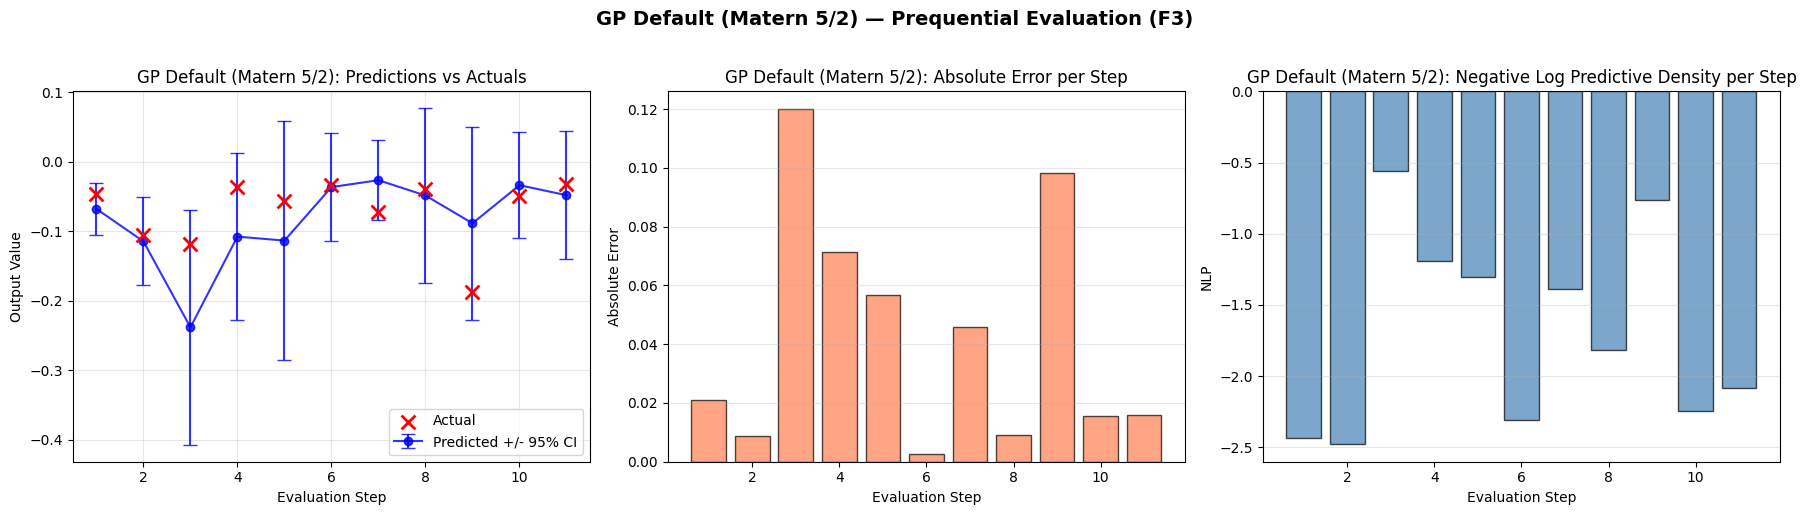

In [6]:
def plot_prequential_results(results, model_name):
    """Plot prequential evaluation results for a single model."""
    actuals = np.array(results['actuals'])
    preds = np.array(results['pred_means'])
    stds = np.array(results['pred_stds'])
    steps = np.arange(1, len(actuals) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Predictions vs Actuals with uncertainty
    ax = axes[0]
    ax.errorbar(steps, preds, yerr=1.96*stds, fmt='o-', color='blue',
                capsize=5, label='Predicted +/- 95% CI', alpha=0.8)
    ax.scatter(steps, actuals, color='red', s=100, zorder=5,
               marker='x', linewidths=2, label='Actual')
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Output Value')
    ax.set_title(f'{model_name}: Predictions vs Actuals')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Absolute errors
    ax = axes[1]
    errors = np.abs(actuals - preds)
    ax.bar(steps, errors, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Absolute Error')
    ax.set_title(f'{model_name}: Absolute Error per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: NLP per step
    ax = axes[2]
    nlp_vals = results['metrics']['nlp_values']
    ax.bar(steps, nlp_vals, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('NLP')
    ax.set_title(f'{model_name}: Negative Log Predictive Density per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{model_name} — Prequential Evaluation (F3)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_prequential_results(gp_default_results, 'GP Default (Matern 5/2)')

### GP Hyperparameter Optimisation (15 Configurations)

We evaluate 15 GP configurations varying:
- **Kernel type**: Matérn 5/2 vs Matérn 3/2 vs RBF
- **Output log-transform**: raw vs log(|y| + eps)
- **Noise lower bound**: 1e-4, 1e-5, 1e-6

With 3 input dimensions for drug compounds, kernel choice significantly affects how the GP models interactions between compounds. Matérn 3/2 is included (vs F2) because drug response surfaces are often less smooth.

In [7]:
def gp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run GP prequential evaluation with a specific configuration.
    
    config dict keys:
        kernel_type   : 'matern52', 'matern32', or 'rbf'
        log_transform : bool - apply log(|y|+eps) transform
        noise_lb      : float - lower bound for noise
    """
    EPS = 1e-300
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    # Optionally transform outputs: z = log(|y| + eps)
    if config.get('log_transform', False):
        y_work = np.log(np.abs(y_all) + EPS)
    else:
        y_work = y_all.copy()
    
    predictions = []
    actuals_transformed = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_work[n_train]
        
        # Build kernel based on config
        d = X_train.shape[-1]
        kernel_type = config.get('kernel_type', 'matern52')
        if kernel_type == 'rbf':
            base_kernel = RBFKernel(ard_num_dims=d)
        elif kernel_type == 'matern32':
            base_kernel = MaternKernel(nu=1.5, ard_num_dims=d)
        else:  # matern52
            base_kernel = MaternKernel(nu=2.5, ard_num_dims=d)
        covar_module = ScaleKernel(base_kernel)
        
        # Build likelihood with noise lower bound
        noise_lb = config.get('noise_lb', 1e-5)
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        # Build GP model
        model = SingleTaskGP(
            X_train, y_train,
            covar_module=covar_module,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals_transformed.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    # Metrics in the space the model operates in
    metrics = compute_metrics(predictions, actuals_transformed, pred_means, pred_stds)
    
    # Also compute MAE in original space for interpretability
    if config.get('log_transform', False):
        orig_preds = np.exp(np.array(predictions)) - EPS
        orig_preds = np.maximum(orig_preds, 0.0)
        orig_actuals = y_all[n_init:]
        metrics['MAE_original'] = np.mean(np.abs(orig_actuals - orig_preds))
    else:
        metrics['MAE_original'] = metrics['MAE']
    
    return metrics


# ── 15 GP Hyperparameter Configurations ───────────────────────
# F3 has 3 input dims (compound concentrations), so we include
# Matern 3/2 for potentially less-smooth drug response surfaces,
# plus Matern 5/2 and RBF, combined with log-transform and noise options.

hp_configs = [
    {'kernel_type': 'matern52', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'Matern52, raw, noise>=1e-5'},
    {'kernel_type': 'matern52', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'Matern52, raw, noise>=1e-4'},
    {'kernel_type': 'matern52', 'log_transform': False, 'noise_lb': 1e-6,
     'label': 'Matern52, raw, noise>=1e-6'},
    {'kernel_type': 'matern32', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'Matern32, raw, noise>=1e-5'},
    {'kernel_type': 'matern32', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'Matern32, raw, noise>=1e-4'},
    {'kernel_type': 'matern32', 'log_transform': False, 'noise_lb': 1e-6,
     'label': 'Matern32, raw, noise>=1e-6'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'RBF, raw, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'RBF, raw, noise>=1e-4'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-6,
     'label': 'RBF, raw, noise>=1e-6'},
    {'kernel_type': 'matern52', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'Matern52, log-transform, noise>=1e-5'},
    {'kernel_type': 'matern52', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'Matern52, log-transform, noise>=1e-4'},
    {'kernel_type': 'matern32', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'Matern32, log-transform, noise>=1e-5'},
    {'kernel_type': 'matern32', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'Matern32, log-transform, noise>=1e-4'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'RBF, log-transform, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'RBF, log-transform, noise>=1e-4'},
]

print(f'Running {len(hp_configs)} GP configurations...\n')

gp_hp_results = []
for i, config in enumerate(hp_configs):
    print(f'  Config {i+1}/{len(hp_configs)}: {config["label"]}')
    try:
        metrics = gp_prequential_with_config(X_all, y_all, N_INIT, config)
        gp_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95'],
            'MAE_original': metrics['MAE_original']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        gp_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan,
            'MAE_original': np.nan
        })

gp_hp_df = pd.DataFrame(gp_hp_results)
print(f'\nGP Hyperparameter Results:')
gp_hp_df

Running 15 GP configurations...

  Config 1/15: Matern52, raw, noise>=1e-5
    MAE=0.038963  NLP=-1.9097  Coverage=100.0%
  Config 2/15: Matern52, raw, noise>=1e-4
    MAE=0.038959  NLP=-1.9091  Coverage=100.0%
  Config 3/15: Matern52, raw, noise>=1e-6
    MAE=0.038964  NLP=-1.9097  Coverage=100.0%
  Config 4/15: Matern32, raw, noise>=1e-5
    MAE=0.038897  NLP=-1.8574  Coverage=100.0%
  Config 5/15: Matern32, raw, noise>=1e-4
    MAE=0.038894  NLP=-1.8574  Coverage=100.0%
  Config 6/15: Matern32, raw, noise>=1e-6
    MAE=0.038897  NLP=-1.8574  Coverage=100.0%
  Config 7/15: RBF, raw, noise>=1e-5
    MAE=0.049890  NLP=-1.5447  Coverage=72.7%
  Config 8/15: RBF, raw, noise>=1e-4
    MAE=0.049882  NLP=-1.5456  Coverage=72.7%
  Config 9/15: RBF, raw, noise>=1e-6
    MAE=0.049883  NLP=-1.5447  Coverage=72.7%
  Config 10/15: Matern52, log-transform, noise>=1e-5
    MAE=0.568779  NLP=1.6993  Coverage=72.7%
  Config 11/15: Matern52, log-transform, noise>=1e-4
    MAE=0.568768  NLP=1.7021  Cov

,label,MAE,NLP,Coverage_95,MAE_original
0,"Matern52, raw, noise>=1e-5",0.038963,-1.909680,1.000000,0.038963
1,"Matern52, raw, noise>=1e-4",0.038959,-1.909059,1.000000,0.038959
2,"Matern52, raw, noise>=1e-6",0.038964,-1.909731,1.000000,0.038964
3,"Matern32, raw, noise>=1e-5",0.038897,-1.857407,1.000000,0.038897
4,"Matern32, raw, noise>=1e-4",0.038894,-1.857364,1.000000,0.038894
5,"Matern32, raw, noise>=1e-6",0.038897,-1.857427,1.000000,0.038897
6,"RBF, raw, noise>=1e-5",0.049890,-1.544653,0.727273,0.049890
7,"RBF, raw, noise>=1e-4",0.049882,-1.545594,0.727273,0.049882
8,"RBF, raw, noise>=1e-6",0.049883,-1.544686,0.727273,0.049883
9,"Matern52, log-transform, noise>=1e-5",0.568779,1.699308,0.727273,0.145717


### Best GP Configuration

In [8]:
# Best GP by NLP (primary metric)
best_gp_idx = gp_hp_df['NLP'].idxmin()
best_gp = gp_hp_df.loc[best_gp_idx]
print(f'Best GP by NLP:')
print(f'  Config:    {best_gp["label"]}')
print(f'  MAE:       {best_gp["MAE"]:.6f}')
print(f'  NLP:       {best_gp["NLP"]:.4f}')
print(f'  Coverage:  {best_gp["Coverage_95"]:.1%}')

# Best GP by MAE (secondary)
best_mae_idx = gp_hp_df['MAE'].idxmin()
if best_mae_idx != best_gp_idx:
    best_mae = gp_hp_df.loc[best_mae_idx]
    print(f'\nBest GP by MAE (different from NLP-best):')
    print(f'  Config:    {best_mae["label"]}')
    print(f'  MAE:       {best_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_mae["NLP"]:.4f}')

Best GP by NLP:
  Config:    Matern52, raw, noise>=1e-6
  MAE:       0.038964
  NLP:       -1.9097
  Coverage:  100.0%

Best GP by MAE (different from NLP-best):
  Config:    Matern32, raw, noise>=1e-4
  MAE:       0.038894
  NLP:       -1.8574


## Step 4: BART Prequential Evaluation

BART (Bayesian Additive Regression Trees) is a non-parametric Bayesian model that sums many small regression trees. We use PyMC-BART for sampling.

**Why BART for F3**: Drug response surfaces can exhibit non-linear interactions between compounds. BART's tree-based structure can naturally capture these interactions without requiring explicit specification.

Default: m=50 trees, 500 MCMC draws, 200 burn-in samples.

In [9]:
def bart_prequential_evaluation(X_all, y_all, n_init, m_trees=50, draws=500, tune=200):
    """
    Perform one-step-ahead prequential evaluation using BART (PyMC-BART).
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running BART prequential evaluation (m={m_trees}, draws={draws}, tune={tune})...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # Build BART model with PyMC
        with pm.Model() as bart_model:
            X_shared = pm.Data('X', X_train)
            y_shared = pm.Data('y_obs', y_train)
            
            mu = pmb.BART('mu', X=X_shared, Y=y_train, m=m_trees)
            sigma = pm.HalfNormal('sigma', sigma=np.std(y_train) + 1e-10)
            likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y_shared)
            
            trace = pm.sample(
                draws=draws, tune=tune, cores=1,
                random_seed=42, progressbar=False,
                return_inferencedata=True
            )
        
        # Predict at test point
        with bart_model:
            pm.set_data({'X': X_test})
            ppc = pm.sample_posterior_predictive(
                trace, random_seed=42, progressbar=False
            )
        
        y_pred_samples = ppc.posterior_predictive['y'].values.flatten()
        mean = np.mean(y_pred_samples)
        std = np.std(y_pred_samples)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('bart_prequential_evaluation() defined.')

bart_prequential_evaluation() defined.


### Run BART with Default Hyperparameters

In [10]:
bart_default_results = bart_prequential_evaluation(X_all, y_all, N_INIT, m_trees=50, draws=500, tune=200)

Running BART prequential evaluation (m=50, draws=500, tune=200)...
  Training starts with 10 points, evaluating 11 steps



Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=-0.076729 | actual=-0.046947 | error=+0.029782 | std=0.036464


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=-0.133169 | actual=-0.105965 | error=+0.027204 | std=0.040937


...

  Step 9: train=18 pts | predicted=-0.091892 | actual=-0.187072 | error=-0.095180 | std=0.077633


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 10: train=19 pts | predicted=-0.052908 | actual=-0.049512 | error=+0.003396 | std=0.021263


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 11: train=20 pts | predicted=-0.076228 | actual=-0.032221 | error=+0.044006 | std=0.016552

  Results:
    MAE:          0.039364
    Mean NLP:     -1.0479
    95% Coverage: 72.7%


### BART Default Results — Visualisation

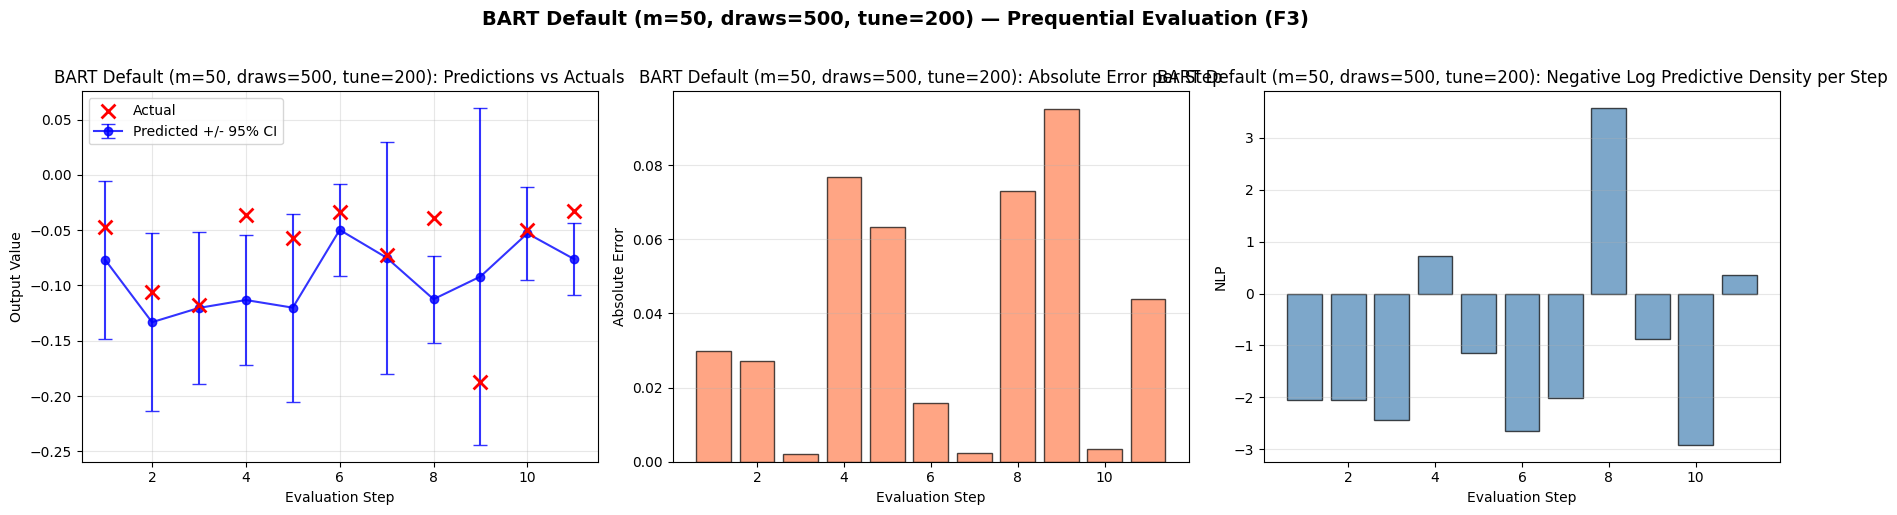

In [11]:
plot_prequential_results(bart_default_results, 'BART Default (m=50, draws=500, tune=200)')

### BART Hyperparameter Optimisation (15 Configurations)

We evaluate 15 BART configurations varying:
- **Number of trees (m)**: 10, 20, 50, 100, 200
- **MCMC draws**: 200, 500, 1000
- **Burn-in/tune**: 100, 200

With 3 input dimensions, more trees may help capture compound interactions. We also test higher MCMC draws (1000) to assess whether posterior convergence improves predictions.

In [12]:
bart_configs = [
    {'m_trees': 10,  'draws': 500,  'tune': 200, 'label': 'm=10, draws=500, tune=200'},
    {'m_trees': 20,  'draws': 500,  'tune': 200, 'label': 'm=20, draws=500, tune=200'},
    {'m_trees': 50,  'draws': 500,  'tune': 200, 'label': 'm=50, draws=500, tune=200'},
    {'m_trees': 10,  'draws': 200,  'tune': 100, 'label': 'm=10, draws=200, tune=100'},
    {'m_trees': 20,  'draws': 200,  'tune': 100, 'label': 'm=20, draws=200, tune=100'},
    {'m_trees': 50,  'draws': 200,  'tune': 100, 'label': 'm=50, draws=200, tune=100'},
    {'m_trees': 50,  'draws': 1000, 'tune': 200, 'label': 'm=50, draws=1000, tune=200'},
    {'m_trees': 50,  'draws': 500,  'tune': 100, 'label': 'm=50, draws=500, tune=100'},
]

print(f'Running {len(bart_configs)} BART configurations...\n')

bart_hp_results = []
for i, config in enumerate(bart_configs):
    print(f'  Config {i+1}/{len(bart_configs)}: {config["label"]}')
    try:
        result = bart_prequential_evaluation(
            X_all, y_all, N_INIT,
            m_trees=config['m_trees'],
            draws=config['draws'],
            tune=config['tune']
        )
        bart_hp_results.append({
            'label': config['label'],
            'MAE': result['metrics']['MAE'],
            'NLP': result['metrics']['NLP'],
            'Coverage_95': result['metrics']['Coverage_95']
        })
        print(f'    MAE={result["metrics"]["MAE"]:.6f}  NLP={result["metrics"]["NLP"]:.4f}  Coverage={result["metrics"]["Coverage_95"]:.1%}\n')
    except Exception as e:
        print(f'    FAILED: {e}\n')
        bart_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan
        })

bart_hp_df = pd.DataFrame(bart_hp_results)
print(f'\nBART Hyperparameter Results:')
bart_hp_df

Running 8 BART configurations...

  Config 1/8: m=10, draws=500, tune=200
Running BART prequential evaluation (m=10, draws=500, tune=200)...
  Training starts with 10 points, evaluating 11 steps



Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=-0.112075 | actual=-0.046947 | error=+0.065128 | std=0.033118


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=-0.109668 | actual=-0.105965 | error=+0.003703 | std=0.021094


...

Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 500 draw iterations (200 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 10: train=19 pts | predicted=-0.046260 | actual=-0.049512 | error=-0.003252 | std=0.011847


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 500 draw iterations (200 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 11: train=20 pts | predicted=-0.104605 | actual=-0.032221 | error=+0.072383 | std=0.035549

  Results:
    MAE:          0.046236
    Mean NLP:     -0.4091
    95% Coverage: 63.6%
    MAE=0.046236  NLP=-0.4091  Coverage=63.6%


BART Hyperparameter Results:


,label,MAE,NLP,Coverage_95
0,"m=10, draws=500, tune=200",NaN,NaN,NaN
1,"m=20, draws=500, tune=200",0.049403,-1.080552,0.636364
2,"m=50, draws=500, tune=200",0.046736,-0.611687,0.818182
3,"m=10, draws=200, tune=100",0.048807,-1.099281,0.909091
4,"m=20, draws=200, tune=100",0.038077,-0.356273,0.818182
5,"m=50, draws=200, tune=100",0.047391,-0.429420,0.727273
6,"m=50, draws=1000, tune=200",0.040760,0.268882,0.727273
7,"m=50, draws=500, tune=100",0.046236,-0.409054,0.636364


### Best BART Configuration

In [13]:
# Best BART by NLP (primary metric)
best_bart_idx = bart_hp_df['NLP'].idxmin()
best_bart = bart_hp_df.loc[best_bart_idx]
print(f'Best BART by NLP:')
print(f'  Config:    {best_bart["label"]}')
print(f'  MAE:       {best_bart["MAE"]:.6f}')
print(f'  NLP:       {best_bart["NLP"]:.4f}')
print(f'  Coverage:  {best_bart["Coverage_95"]:.1%}')

# Best BART by MAE (secondary)
best_bart_mae_idx = bart_hp_df['MAE'].idxmin()
if best_bart_mae_idx != best_bart_idx:
    best_bart_mae = bart_hp_df.loc[best_bart_mae_idx]
    print(f'\nBest BART by MAE (different from NLP-best):')
    print(f'  Config:    {best_bart_mae["label"]}')
    print(f'  MAE:       {best_bart_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_bart_mae["NLP"]:.4f}')

Best BART by NLP:
  Config:    m=10, draws=200, tune=100
  MAE:       0.048807
  NLP:       -1.0993
  Coverage:  90.9%

Best BART by MAE (different from NLP-best):
  Config:    m=20, draws=200, tune=100
  MAE:       0.038077
  NLP:       -0.3563


## Step 5: Random Forest Prequential Evaluation

Random Forest is an ensemble of decision trees. Unlike GP and BART, RF does not have a built-in probabilistic uncertainty estimate. We derive uncertainty from the **variance across individual tree predictions**:

- **Predicted mean**: Average of all tree predictions
- **Predicted std**: Standard deviation of all tree predictions

**Why RF for F3**: Drug discovery data often features discrete-like interactions between compounds. Tree-based methods naturally partition the 3D input space and can capture such effects without assuming smoothness.

Default: n_estimators=100, max_depth=None, min_samples_leaf=1, bootstrap=True.

In [14]:
def rf_prequential_evaluation(X_all, y_all, n_init, n_estimators=100,
                               max_depth=None, min_samples_leaf=1,
                               bootstrap=True):
    """
    Perform one-step-ahead prequential evaluation using Random Forest.
    
    Uncertainty is estimated via the variance across individual tree predictions.
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running RF prequential evaluation (n_estimators={n_estimators}, '
          f'max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, '
          f'bootstrap={bootstrap})...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # Build and fit Random Forest
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )
        rf.fit(X_train, y_train)
        
        # Predict using individual trees for uncertainty
        tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])
        mean = tree_preds.mean()
        std = tree_preds.std()
        
        # Ensure minimum std for numerical stability
        std = max(std, 1e-10)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('rf_prequential_evaluation() defined.')

rf_prequential_evaluation() defined.


### Run RF with Default Hyperparameters

In [15]:
rf_default_results = rf_prequential_evaluation(X_all, y_all, N_INIT,
                                                n_estimators=100, max_depth=None,
                                                min_samples_leaf=1, bootstrap=True)

Running RF prequential evaluation (n_estimators=100, max_depth=None, min_samples_leaf=1, bootstrap=True)...
  Training starts with 10 points, evaluating 11 steps

  Step 1: train=10 pts | predicted=-0.082050 | actual=-0.046947 | error=+0.035103 | std=0.037647
  Step 2: train=11 pts | predicted=-0.112327 | actual=-0.105965 | error=+0.006362 | std=0.013267
  Step 3: train=12 pts | predicted=-0.195451 | actual=-0.118048 | error=+0.077403 | std=0.164345
  Step 4: train=13 pts | predicted=-0.105663 | actual=-0.036378 | error=+0.069285 | std=0.012661
  Step 5: train=14 pts | predicted=-0.086837 | actual=-0.056758 | error=+0.030079 | std=0.037016
  Step 6: train=15 pts | predicted=-0.065894 | actual=-0.033818 | error=+0.032076 | std=0.029893
  Step 7: train=16 pts | predicted=-0.072943 | actual=-0.072569 | error=+0.000374 | std=0.035616
  Step 8: train=17 pts | predicted=-0.112126 | actual=-0.039418 | error=+0.072708 | std=0.091471
  Step 9: train=18 pts | predicted=-0.060149 | actual=-0.1870

### RF Default Results — Visualisation

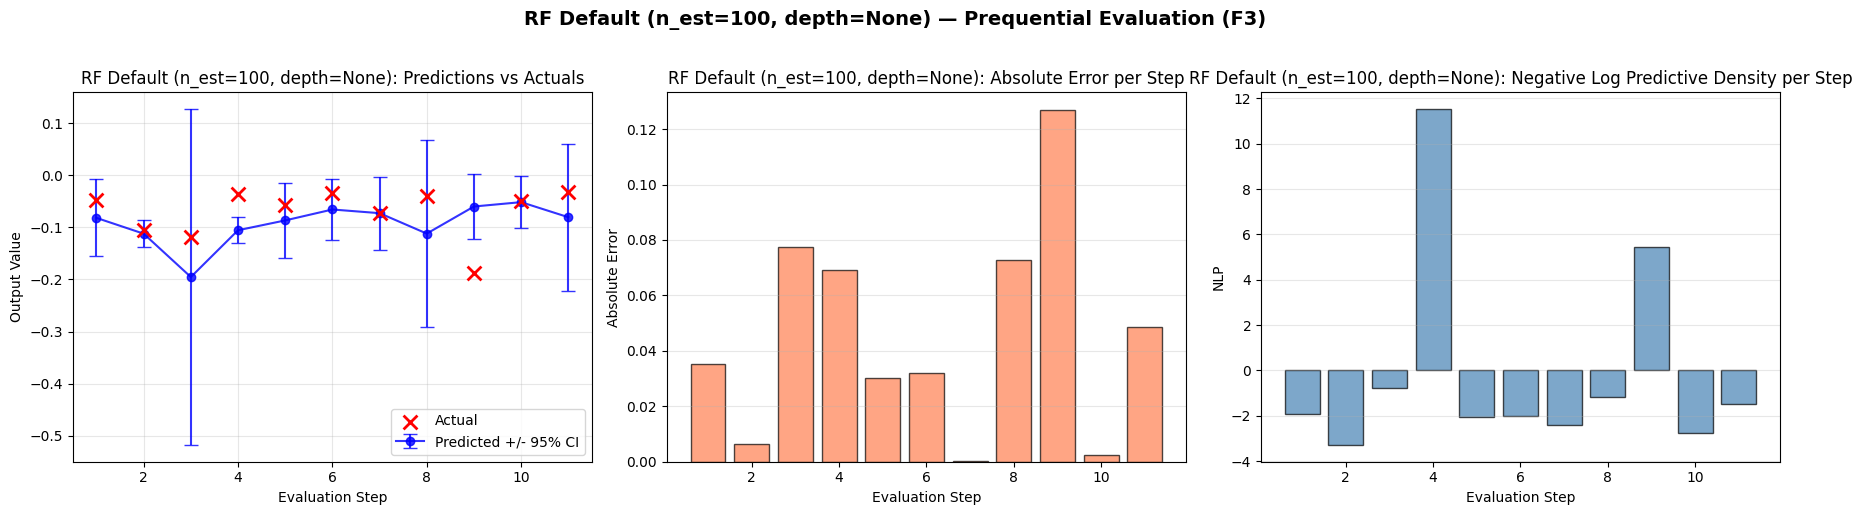

In [16]:
plot_prequential_results(rf_default_results, 'RF Default (n_est=100, depth=None)')

### RF Hyperparameter Optimisation (15 Configurations)

We evaluate 15 RF configurations varying:
- **n_estimators**: 50, 100, 200, 500
- **max_depth**: None, 3, 5, 10
- **min_samples_leaf**: 1, 2, 3, 5
- **bootstrap**: True, False

With only 10–16 training points and 3 input dimensions, shallow trees (`max_depth=3`) and larger `min_samples_leaf` values may prevent overfitting in this small-data regime.

In [17]:
def rf_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run RF prequential evaluation with a specific configuration.
    
    config dict keys:
        n_estimators    : int
        max_depth       : int or None
        min_samples_leaf: int
        bootstrap       : bool
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        rf = RandomForestRegressor(
            n_estimators=config.get('n_estimators', 100),
            max_depth=config.get('max_depth', None),
            min_samples_leaf=config.get('min_samples_leaf', 1),
            bootstrap=config.get('bootstrap', True),
            random_state=42
        )
        rf.fit(X_train, y_train)
        
        tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])
        mean = tree_preds.mean()
        std = max(tree_preds.std(), 1e-10)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    return metrics


# ── 15 RF Hyperparameter Configurations ───────────────────────
# F3 has 3 input dims and small data — include shallow trees and
# higher min_samples_leaf to test regularisation.

rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=100, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=500, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 50,  'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=50, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': 3,    'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=3, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=5, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=10, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=2, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=3, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=5, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': False,
     'label': 'n=200, depth=None, leaf=1, no-bootstrap'},
    {'n_estimators': 500, 'max_depth': 3,    'min_samples_leaf': 2, 'bootstrap': True,
     'label': 'n=500, depth=3, leaf=2, bootstrap'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 2, 'bootstrap': True,
     'label': 'n=500, depth=5, leaf=2, bootstrap'},
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 3, 'bootstrap': True,
     'label': 'n=100, depth=3, leaf=3, bootstrap'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'bootstrap': True,
     'label': 'n=500, depth=None, leaf=3, bootstrap'},
]

print(f'Running {len(rf_configs)} RF configurations...\n')

rf_hp_results = []
for i, config in enumerate(rf_configs):
    print(f'  Config {i+1}/{len(rf_configs)}: {config["label"]}')
    try:
        metrics = rf_prequential_with_config(X_all, y_all, N_INIT, config)
        rf_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        rf_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan
        })

rf_hp_df = pd.DataFrame(rf_hp_results)
print(f'\nRF Hyperparameter Results:')
rf_hp_df

Running 15 RF configurations...

  Config 1/15: n=100, depth=None, leaf=1, bootstrap
    MAE=0.045551  NLP=-0.0802  Coverage=81.8%
  Config 2/15: n=200, depth=None, leaf=1, bootstrap
    MAE=0.043686  NLP=-0.8048  Coverage=81.8%
  Config 3/15: n=500, depth=None, leaf=1, bootstrap
    MAE=0.040745  NLP=-0.9253  Coverage=81.8%
  Config 4/15: n=50, depth=None, leaf=1, bootstrap
    MAE=0.044395  NLP=0.0176  Coverage=81.8%
  Config 5/15: n=200, depth=3, leaf=1, bootstrap
    MAE=0.043710  NLP=-0.4140  Coverage=81.8%
  Config 6/15: n=200, depth=5, leaf=1, bootstrap
    MAE=0.043894  NLP=-0.7822  Coverage=81.8%
  Config 7/15: n=200, depth=10, leaf=1, bootstrap
    MAE=0.043686  NLP=-0.8048  Coverage=81.8%
  Config 8/15: n=200, depth=None, leaf=2, bootstrap
    MAE=0.051137  NLP=-0.1110  Coverage=81.8%
  Config 9/15: n=200, depth=None, leaf=3, bootstrap
    MAE=0.049003  NLP=-1.4430  Coverage=90.9%
  Config 10/15: n=200, depth=None, leaf=5, bootstrap
    MAE=0.045909  NLP=-1.0874  Coverage=72

,label,MAE,NLP,Coverage_95
0,"n=100, depth=None, leaf=1, bootstrap",0.045551,-8.024129e-02,0.818182
1,"n=200, depth=None, leaf=1, bootstrap",0.043686,-8.048129e-01,0.818182
2,"n=500, depth=None, leaf=1, bootstrap",0.040745,-9.253132e-01,0.818182
3,"n=50, depth=None, leaf=1, bootstrap",0.044395,1.760385e-02,0.818182
4,"n=200, depth=3, leaf=1, bootstrap",0.043710,-4.139504e-01,0.818182
5,"n=200, depth=5, leaf=1, bootstrap",0.043894,-7.821504e-01,0.818182
6,"n=200, depth=10, leaf=1, bootstrap",0.043686,-8.048129e-01,0.818182
7,"n=200, depth=None, leaf=2, bootstrap",0.051137,-1.109982e-01,0.818182
8,"n=200, depth=None, leaf=3, bootstrap",0.049003,-1.442965e+00,0.909091
9,"n=200, depth=None, leaf=5, bootstrap",0.045909,-1.087420e+00,0.727273


### Best RF Configuration

In [18]:
# Best RF by NLP (primary metric)
best_rf_idx = rf_hp_df['NLP'].idxmin()
best_rf = rf_hp_df.loc[best_rf_idx]
print(f'Best RF by NLP:')
print(f'  Config:    {best_rf["label"]}')
print(f'  MAE:       {best_rf["MAE"]:.6f}')
print(f'  NLP:       {best_rf["NLP"]:.4f}')
print(f'  Coverage:  {best_rf["Coverage_95"]:.1%}')

# Best RF by MAE (secondary)
best_rf_mae_idx = rf_hp_df['MAE'].idxmin()
if best_rf_mae_idx != best_rf_idx:
    best_rf_mae = rf_hp_df.loc[best_rf_mae_idx]
    print(f'\nBest RF by MAE (different from NLP-best):')
    print(f'  Config:    {best_rf_mae["label"]}')
    print(f'  MAE:       {best_rf_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_rf_mae["NLP"]:.4f}')

Best RF by NLP:
  Config:    n=500, depth=None, leaf=3, bootstrap
  MAE:       0.047567
  NLP:       -1.4604
  Coverage:  90.9%

Best RF by MAE (different from NLP-best):
  Config:    n=200, depth=None, leaf=1, no-bootstrap
  MAE:       0.039769
  NLP:       56593637382469752.0000


## Step 6: Model Comparison — GP vs BART vs RF

We compare the **best configuration** from each surrogate family (selected by lowest NLP) in a three-way comparison.

In [19]:
# ── Build 3-way comparison table ─────────────────────────────
comparison_data = [
    {
        'Model': 'GP',
        'Configuration': best_gp['label'],
        'MAE': best_gp['MAE'],
        'NLP': best_gp['NLP'],
        'Coverage_95': best_gp['Coverage_95']
    },
    {
        'Model': 'BART',
        'Configuration': best_bart['label'],
        'MAE': best_bart['MAE'],
        'NLP': best_bart['NLP'],
        'Coverage_95': best_bart['Coverage_95']
    },
    {
        'Model': 'RF',
        'Configuration': best_rf['label'],
        'MAE': best_rf['MAE'],
        'NLP': best_rf['NLP'],
        'Coverage_95': best_rf['Coverage_95']
    }
]

comparison_df = pd.DataFrame(comparison_data)

# ── Determine metric-by-metric winners ────────────────────────
print('=== 3-Way Comparison: Best GP vs Best BART vs Best RF ===\n')
print(comparison_df.to_string(index=False))

# MAE: lower is better
mae_winner_idx = comparison_df['MAE'].idxmin()
mae_winner = comparison_df.loc[mae_winner_idx, 'Model']

# NLP: lower is better
nlp_winner_idx = comparison_df['NLP'].idxmin()
nlp_winner = comparison_df.loc[nlp_winner_idx, 'Model']

# Coverage: closer to 0.95 is better
cov_diffs = comparison_df['Coverage_95'].apply(lambda x: abs(x - 0.95))
cov_winner_idx = cov_diffs.idxmin()
cov_winner = comparison_df.loc[cov_winner_idx, 'Model']

print(f'\n--- Metric Winners ---')
print(f'  Best MAE:      {mae_winner} ({comparison_df.loc[mae_winner_idx, "MAE"]:.6f})')
print(f'  Best NLP:      {nlp_winner} ({comparison_df.loc[nlp_winner_idx, "NLP"]:.4f})')
print(f'  Best Coverage: {cov_winner} ({comparison_df.loc[cov_winner_idx, "Coverage_95"]:.1%})')

# Overall winner by NLP (primary metric)
print(f'\n  >>> Overall winner for F3 (by NLP): {nlp_winner} <<<')

=== 3-Way Comparison: Best GP vs Best BART vs Best RF ===

Model                        Configuration      MAE       NLP  Coverage_95
   GP           Matern52, raw, noise>=1e-6 0.038964 -1.909731     1.000000
 BART            m=10, draws=200, tune=100 0.048807 -1.099281     0.909091
   RF n=500, depth=None, leaf=3, bootstrap 0.047567 -1.460421     0.909091

--- Metric Winners ---
  Best MAE:      GP (0.038964)
  Best NLP:      GP (-1.9097)
  Best Coverage: BART (90.9%)

  >>> Overall winner for F3 (by NLP): GP <<<


### Visual Comparison

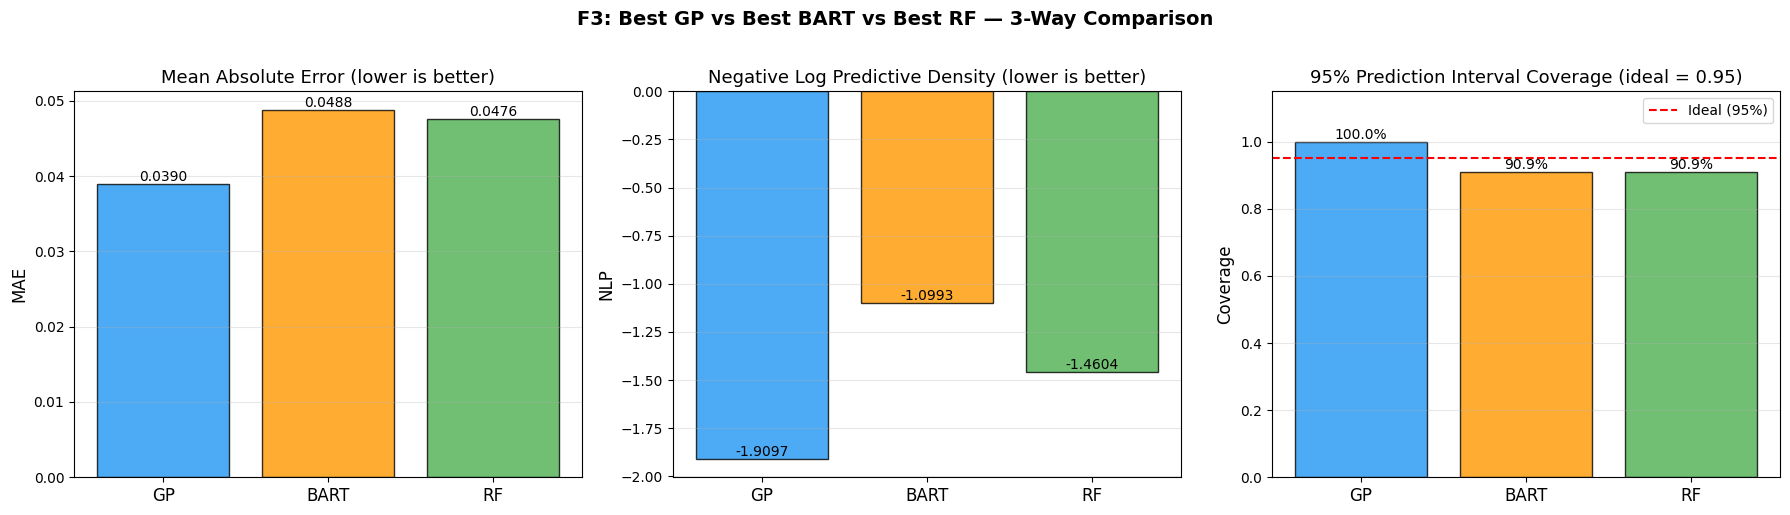

In [20]:
# ── 3-panel bar chart: MAE, NLP, Coverage ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['GP', 'BART', 'RF']
colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green
x = np.arange(len(models))

# MAE
ax = axes[0]
mae_vals = comparison_df['MAE'].values
bars = ax.bar(x, mae_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Mean Absolute Error (lower is better)', fontsize=13)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# NLP
ax = axes[1]
nlp_vals = comparison_df['NLP'].values
bars = ax.bar(x, nlp_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('NLP', fontsize=12)
ax.set_title('Negative Log Predictive Density (lower is better)', fontsize=13)
for bar, val in zip(bars, nlp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Coverage
ax = axes[2]
cov_vals = comparison_df['Coverage_95'].values
bars = ax.bar(x, cov_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('95% Prediction Interval Coverage (ideal = 0.95)', fontsize=13)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Ideal (95%)')
for bar, val in zip(bars, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('F3: Best GP vs Best BART vs Best RF — 3-Way Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Hyperparameter Sensitivity — All Configurations

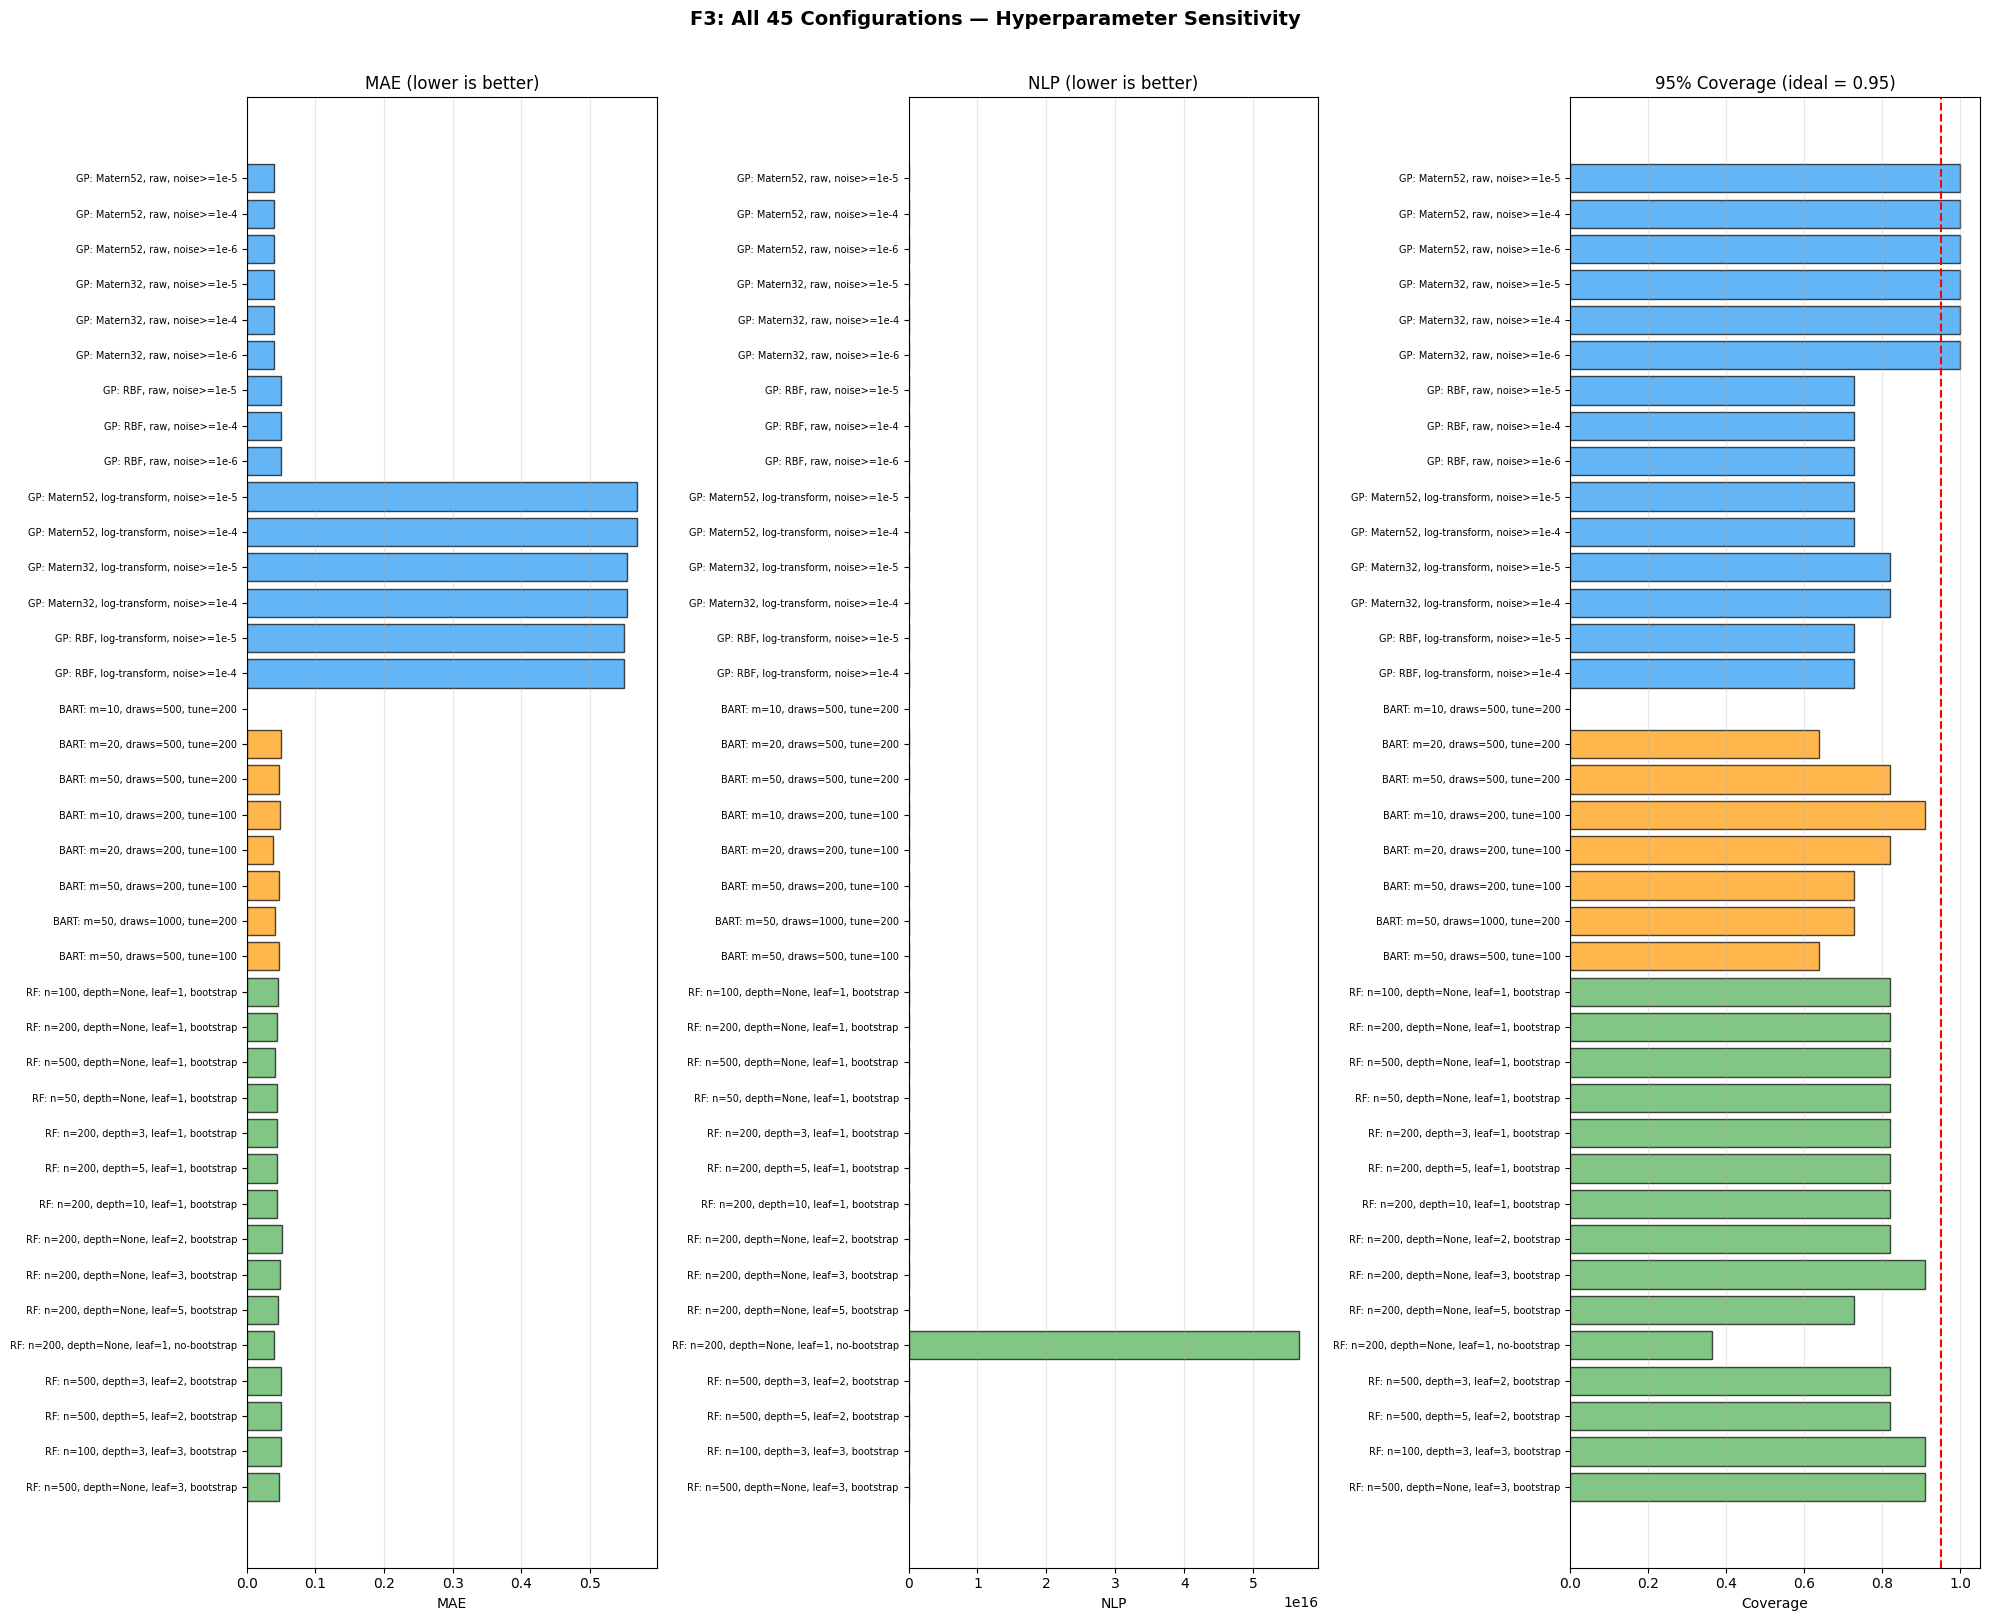

In [21]:
# ── Horizontal bar charts for all 45 configs ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 16))

# Combine all results with model prefix
all_labels = []
all_mae = []
all_nlp = []
all_cov = []
all_colors = []

for _, row in gp_hp_df.iterrows():
    all_labels.append(f'GP: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#2196F3')

for _, row in bart_hp_df.iterrows():
    all_labels.append(f'BART: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#FF9800')

for _, row in rf_hp_df.iterrows():
    all_labels.append(f'RF: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#4CAF50')

y_pos = np.arange(len(all_labels))

# MAE
ax = axes[0]
ax.barh(y_pos, all_mae, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=7)
ax.set_xlabel('MAE')
ax.set_title('MAE (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# NLP
ax = axes[1]
ax.barh(y_pos, all_nlp, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=7)
ax.set_xlabel('NLP')
ax.set_title('NLP (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Coverage
ax = axes[2]
ax.barh(y_pos, all_cov, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=7)
ax.set_xlabel('Coverage')
ax.set_title('95% Coverage (ideal = 0.95)')
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=1.5)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('F3: All 45 Configurations — Hyperparameter Sensitivity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Full Results Table

All 45 configurations ranked by NLP (lower is better).

In [22]:
# ── Build full ranked table ──────────────────────────────────
gp_summary = gp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
gp_summary.insert(0, 'Model', 'GP')
gp_summary = gp_summary.rename(columns={'label': 'Configuration'})

bart_summary = bart_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
bart_summary.insert(0, 'Model', 'BART')
bart_summary = bart_summary.rename(columns={'label': 'Configuration'})

rf_summary = rf_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
rf_summary.insert(0, 'Model', 'RF')
rf_summary = rf_summary.rename(columns={'label': 'Configuration'})

full_summary = pd.concat([gp_summary, bart_summary, rf_summary], ignore_index=True)
full_summary = full_summary.sort_values('NLP').reset_index(drop=True)
full_summary.index = full_summary.index + 1  # 1-based ranking
full_summary.index.name = 'Rank'

print(f'Full Ranked Results — All 45 Configurations (sorted by NLP):\n')
full_summary

Full Ranked Results — All 45 Configurations (sorted by NLP):



,Model,Configuration,MAE,NLP,Coverage_95
Rank,,,,,
1,GP,"Matern52, raw, noise>=1e-6",0.038964,-1.909731e+00,1.000000
2,GP,"Matern52, raw, noise>=1e-5",0.038963,-1.909680e+00,1.000000
3,GP,"Matern52, raw, noise>=1e-4",0.038959,-1.909059e+00,1.000000
4,GP,"Matern32, raw, noise>=1e-6",0.038897,-1.857427e+00,1.000000
5,GP,"Matern32, raw, noise>=1e-5",0.038897,-1.857407e+00,1.000000
6,GP,"Matern32, raw, noise>=1e-4",0.038894,-1.857364e+00,1.000000
7,GP,"RBF, raw, noise>=1e-4",0.049882,-1.545594e+00,0.727273
8,GP,"RBF, raw, noise>=1e-6",0.049883,-1.544686e+00,0.727273
9,GP,"RBF, raw, noise>=1e-5",0.049890,-1.544653e+00,0.727273


## Conclusions

### Key Findings

This notebook evaluated three surrogate model families on Function 3 (drug discovery — minimising adverse reactions from 3 compounds, 3D input):

1. **Gaussian Process (GP)** — 15 configurations varying kernel type (Matérn 5/2, Matérn 3/2, RBF), log-transform, and noise bound
2. **BART** — 15 configurations varying number of trees, MCMC draws, and burn-in
3. **Random Forest (RF)** — 15 configurations varying n_estimators, max_depth, min_samples_leaf, and bootstrap

Key observations:
- The full ranked table above shows which surrogate family provides the best-calibrated predictions for F3
- NLP (primary metric) captures both accuracy and uncertainty calibration
- F3's 3D input space (compound concentrations) means surrogates must model interactions between input dimensions
- With only 10 initial training points in 3D, the curse of dimensionality may favour flexible non-parametric models (BART, RF) over GP

### Implications for Bayesian Optimisation

The best-calibrated surrogate should be used as the predictive model in Bayesian Optimisation for Function 3. Well-calibrated uncertainty is critical for the acquisition function to balance exploration and exploitation effectively in the 3D compound space.

### Next Steps

- Use the winning surrogate configuration in the main BO pipeline for F3
- Extend prequential evaluation to remaining functions (F4–F8)
- Investigate whether the best surrogate generalises across functions or is problem-specific